In [1]:
import sys, torch
sys.path.insert(0, "qwen3")                      # match the architecture of the checkpoint
from model import TinyQwen
from tokenizer import CharTokenizer


In [7]:
[[1, 4],
 [2, 5],
 [4, 1],
 [5, 3]]

[[1, 4], [2, 5], [4, 1], [5, 3]]

In [14]:

ckpt = torch.load("qwen3/tiny_qwen.pt", map_location="cpu", weights_only=False)
tok = CharTokenizer(ckpt["chars"])
model = TinyQwen(ckpt["cfg"]); model.load_state_dict(ckpt["model"]); model.eval()

model

TinyQwen(
  (embed_tokens): Embedding(30, 32)
  (layers): ModuleList(
    (0-1): 2 x TransformerBlock(
      (input_layernorm): RMSNorm()
      (attn): Attention(
        (q_proj): Linear(in_features=32, out_features=32, bias=False)
        (k_proj): Linear(in_features=32, out_features=16, bias=False)
        (v_proj): Linear(in_features=32, out_features=16, bias=False)
        (o_proj): Linear(in_features=32, out_features=32, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (post_attention_layernorm): RMSNorm()
      (mlp): MLP(
        (gate_proj): Linear(in_features=32, out_features=64, bias=False)
        (up_proj): Linear(in_features=32, out_features=64, bias=False)
        (down_proj): Linear(in_features=64, out_features=32, bias=False)
      )
    )
  )
  (norm): RMSNorm()
  (lm_head): Linear(in_features=32, out_features=30, bias=False)
)

In [13]:
# parameters count model.parameters()

count = sum(p.numel() for p in model.parameters())
count

197

In [3]:
tok.encode("a")

[1]

In [4]:
tok.decode([0])

'\n'

In [10]:
model.embed_tokens.weight

Parameter containing:
tensor([[-2.5944e-02, -1.6900e-01, -3.9246e-01, -6.5868e-01,  6.8594e-01,
          2.8532e-02,  8.0508e-01,  1.3097e-02,  2.2318e-01,  1.0939e+00,
         -1.2547e+00, -4.1369e-01,  2.7395e-02, -3.2181e-01, -9.3094e-01,
          1.4433e+00,  1.2704e+00, -2.8189e-01,  3.3240e-01,  7.3917e-01,
         -1.7423e+00,  4.6255e-01,  1.3125e+00,  5.9483e-01,  2.2652e-01,
         -1.3165e+00, -1.1114e+00, -3.3506e-01,  4.1677e-01, -5.5589e-01,
          1.4281e+00,  2.4521e+00],
        [-6.3702e-01, -2.9985e-01,  7.1826e-01,  2.2338e-01,  1.0081e-02,
          8.4068e-01, -1.0365e+00, -3.6484e-01, -5.1324e-01, -8.9334e-01,
          5.1905e-01, -1.3854e+00, -1.0952e+00,  4.6777e-01, -4.6868e-01,
         -6.0839e-01,  1.5581e+00, -6.8748e-01,  1.2181e+00, -2.0418e-01,
         -1.2345e+00,  1.9673e+00,  2.5926e+00, -1.5755e+00,  1.1150e+00,
         -1.0973e+00,  5.7085e-01, -2.4900e-01,  4.6836e-01,  1.5202e+00,
          1.4613e+00, -3.1769e-01],
        [-5.0053e-

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

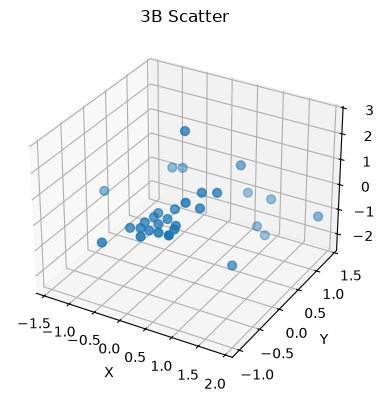

In [7]:
points = model.embed_tokens.weight.detach().cpu().numpy()
# 3B görselleştirme
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(points[:, 0], points[:, 1], points[:, 2], s=40)
ax1.set_title("3B Scatter")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

plt.tight_layout()
plt.show()

In [8]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers+text",
            text=[str(i) for i in range(len(points))],
            textposition="top center",
            marker=dict(
                size=5,
                color=np.arange(len(points)),
                colorscale="Viridis",
                opacity=0.9,
            ),
        )
    ]
)

fig.update_layout(
    title="3B Nokta Görselleştirme",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

In [14]:
model.embed_tokens.weight[1]

tensor([ 1.0408,  1.7958, -0.9973], grad_fn=<SelectBackward0>)

In [7]:
start = torch.full((10, 1), tok.eos_id, dtype=torch.long)   # every name starts at EOS/newline
out = model.generate(start, max_new_tokens=model.cfg.max_seq_len,
                     temperature=0.8, eos_id=tok.eos_id)     # stops each row at EOS
out

tensor([[ 0,  2,  5,  8,  1, 14,  0],
        [ 0, 20, 17,  1, 13,  0,  0],
        [ 0, 18,  5,  8,  5,  0,  0],
        [ 0,  5, 13,  0,  0,  0,  0],
        [ 0,  6,  9, 14,  0,  0,  0],
        [ 0, 24,  1,  0,  0,  0,  0],
        [ 0,  6,  1, 17, 11,  0,  0],
        [ 0, 20, 17, 26, 27,  1,  0],
        [ 0,  3,  1, 17,  1,  0,  0],
        [ 0,  5, 12,  5,  0,  0,  0]])

In [8]:
for row in out.tolist():
    print(tok.decode(row[1:]).split("\n")[0])

behan
uram
sehe
em
fin
ça
fark
urüğa
cara
ele


## LoRA adaptörü ekleyelim

Yukarıda eğittiğimiz `model` (197 parametreli TinyQwen) burada aynen kalacak — donduracağız. `lora/` klasöründeki hazır kod ile üstüne birkaç yüz parametrelik minik bir adaptör takıp sadece onu eğiteceğiz. Adımlar:

1. `lora/` klasörünü import path'ine ekle, `LoRAConfig` ve `inject` araçlarını çek.
2. Hangi `Linear` katmanlarını adapte edebileceğimizi gör (`print_linear_names`).
3. Adaptörü tak (`inject`) ve **modelin yeni yapısını yazdır** — `Linear` katmanların yerini `LoRALinear` (base + lora_A + lora_B) alacak.
4. Eğitilebilir/toplam parametre oranına bak.
5. Tek bir harfle başlayan isimlerden minik bir eğitim verisiyle sadece adaptörü eğit.
6. Adaptör açık/kapalıyken üretimi karşılaştır.
7. Adaptörü diske kaydet ve içindeki tensörlerin (adaptörün gerçek "yapısı") şekillerini yazdır.


In [15]:
# 1) lora/ klasöründeki hazır kodu import edelim
sys.path.insert(0, "lora")
from lora import LoRAConfig
from inject import (inject, set_adapters, merge_adapters, print_parameter_report,
                    print_linear_names, save_adapter)

# 2) hangi Linear katmanları adapte edilebilir?
print_linear_names(model)


  adaptable nn.Linear layers (leaf name in brackets):
    layers.0.attn.q_proj               [  32 x   32]  (q_proj)
    layers.0.attn.k_proj               [  16 x   32]  (k_proj)
    layers.0.attn.v_proj               [  16 x   32]  (v_proj)
    layers.0.attn.o_proj               [  32 x   32]  (o_proj)
    layers.0.mlp.gate_proj             [  64 x   32]  (gate_proj)
    layers.0.mlp.up_proj               [  64 x   32]  (up_proj)
    layers.0.mlp.down_proj             [  32 x   64]  (down_proj)
    layers.1.attn.q_proj               [  32 x   32]  (q_proj)
    layers.1.attn.k_proj               [  16 x   32]  (k_proj)
    layers.1.attn.v_proj               [  16 x   32]  (v_proj)
    layers.1.attn.o_proj               [  32 x   32]  (o_proj)
    layers.1.mlp.gate_proj             [  64 x   32]  (gate_proj)
    layers.1.mlp.up_proj               [  64 x   32]  (up_proj)
    layers.1.mlp.down_proj             [  32 x   64]  (down_proj)
    lm_head                            [  30 x   3

In [16]:
# 3) adaptörü tak: q_proj ve v_proj'a LoRA (orijinal makaledeki klasik seçim), r=4
lcfg = LoRAConfig(r=4, alpha=8.0, targets=("q_proj", "v_proj"))
adapted_layers = inject(model, lcfg, method="lora")
print("adapte edilen katmanlar:", adapted_layers)

model   # <- adaptörün yapısı: Linear yerine LoRALinear(base, lora_A, lora_B)


adapte edilen katmanlar: ['layers.0.attn.q_proj', 'layers.0.attn.v_proj', 'layers.1.attn.q_proj', 'layers.1.attn.v_proj']


TinyQwen(
  (embed_tokens): Embedding(30, 32)
  (layers): ModuleList(
    (0-1): 2 x TransformerBlock(
      (input_layernorm): RMSNorm()
      (attn): Attention(
        (q_proj): LoRALinear(
          (base): Linear(in_features=32, out_features=32, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (k_proj): Linear(in_features=32, out_features=16, bias=False)
        (v_proj): LoRALinear(
          (base): Linear(in_features=32, out_features=16, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (o_proj): Linear(in_features=32, out_features=32, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (post_attention_layernorm): RMSNorm()
      (mlp): MLP(
        (gate_proj): Linear(in_features=32, out_features=64, bias=False)
        (up_proj): Linear(in_features=32, out_features=64, bias=False)
        (down_proj): Linear(in_features=64, out_features=32, bias=False)
      )
    )
  )
  (norm): RMSN

In [17]:
# 4) eğitilebilir / toplam parametre oranı (adaptör ne kadar küçük?)
print_parameter_report(model)


  trainable: 896 / 20,480 (4.38% of the model)


In [18]:
# 5) minik eğitim verisi: sadece 'z' ile başlayan isimler
letter = "z"
raw = open("data/temiz_isimler.txt", encoding="utf-8").read().split("\n")
names = [n for n in raw if n and n[0] == letter]
text = "\n" + "\n".join(names) + "\n"
data = torch.tensor(tok.encode(text), dtype=torch.long)
print(f"{len(names)} tane '{letter}' ile başlayan isim, {len(data)} karakter")

BLOCK_SIZE, BATCH_SIZE, STEPS, LR = 16, 64, 300, 5e-3
torch.manual_seed(0)

def get_batch(data):
    ix = torch.randint(len(data) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([data[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + BLOCK_SIZE] for i in ix])
    return x, y

# sadece requires_grad=True olanlar (yani adaptör) optimize edilir, base donuk kalır
opt = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=LR)
model.train()
for step in range(1, STEPS + 1):
    x, y = get_batch(data)
    _, loss = model(x, y)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 50 == 0 or step == 1:
        print(f"step {step:4d}  loss {loss.item():.4f}")
model.eval()


20 tane 'z' ile başlayan isim, 140 karakter
step    1  loss 2.7268
step   50  loss 0.6661
step  100  loss 0.4542
step  150  loss 0.3369
step  200  loss 0.3111
step  250  loss 0.2876
step  300  loss 0.2848


TinyQwen(
  (embed_tokens): Embedding(30, 32)
  (layers): ModuleList(
    (0-1): 2 x TransformerBlock(
      (input_layernorm): RMSNorm()
      (attn): Attention(
        (q_proj): LoRALinear(
          (base): Linear(in_features=32, out_features=32, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (k_proj): Linear(in_features=32, out_features=16, bias=False)
        (v_proj): LoRALinear(
          (base): Linear(in_features=32, out_features=16, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (o_proj): Linear(in_features=32, out_features=32, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (post_attention_layernorm): RMSNorm()
      (mlp): MLP(
        (gate_proj): Linear(in_features=32, out_features=64, bias=False)
        (up_proj): Linear(in_features=32, out_features=64, bias=False)
        (down_proj): Linear(in_features=64, out_features=32, bias=False)
      )
    )
  )
  (norm): RMSN

In [19]:
# 6) adaptör açık/kapalı karşılaştırması
@torch.no_grad()
def sample(n=20):
    start = torch.full((n, 1), tok.eos_id, dtype=torch.long)
    out = model.generate(start, max_new_tokens=model.cfg.max_seq_len,
                         temperature=0.8, eos_id=tok.eos_id)
    names = [tok.decode(r[1:]).split("\n")[0] for r in out.tolist()]
    return [nm for nm in names if nm]

set_adapters(model, True)
print("adaptör AÇIK :", sample())
set_adapters(model, False)
print("adaptör KAPALI (orijinal model):", sample())
set_adapters(model, True)   # devam için tekrar açık bırak


adaptör AÇIK : ['zzen', 'zerin', 'zerrin', 'zekihan', 'zürhatiekin', 'zühtü', 'zekeriya', 'cema', 'cemilek', 'zülfç', 'zerrin', 'zerin', 'zerffe', 'zühre', 'zerrin', 'zühtü', 'zünade', 'zekeriya', 'zekeriya', 'zekeriya']
adaptör KAPALI (orijinal model): ['burhan', 'sertan', 'ergün', 'seberç', 'yunus', 'dertat', 'gümen', 'alican', 'sedat', 'sebedç', 'gülcu', 'sebedk', 'baylat', 'ahsen', 'erdar', 'arzullaf', 'bedriye', 'mehrali', 'bebrail', 'tansu']


In [20]:
# 7) adaptörü diske kaydet ve içindeki tensörlerin gerçek "yapısını" yazdır
adapter_path = f"qwen3/adapter_{letter}.pt"
save_adapter(model, adapter_path, "lora", lcfg, arch="qwen3")

adapter_ckpt = torch.load(adapter_path, map_location="cpu", weights_only=False)
print(f"method={adapter_ckpt['method']}   cfg={adapter_ckpt['cfg']}\n")
for name, tensor in adapter_ckpt["adapter"].items():
    print(f"{name:30s} {tuple(tensor.shape)}")


method=lora   cfg=LoRAConfig(r=4, alpha=8.0, dropout=0.0, rank_stabilized=False, targets=('q_proj', 'v_proj'))

layers.0.attn.q_proj.lora_A    (4, 32)
layers.0.attn.q_proj.lora_B    (32, 4)
layers.0.attn.v_proj.lora_A    (4, 32)
layers.0.attn.v_proj.lora_B    (16, 4)
layers.1.attn.q_proj.lora_A    (4, 32)
layers.1.attn.q_proj.lora_B    (32, 4)
layers.1.attn.v_proj.lora_A    (4, 32)
layers.1.attn.v_proj.lora_B    (16, 4)


In [21]:
adapter_ckpt

{'arch': 'qwen3',
 'method': 'lora',
 'cfg': LoRAConfig(r=4, alpha=8.0, dropout=0.0, rank_stabilized=False, targets=('q_proj', 'v_proj')),
 'adapter': {'layers.0.attn.q_proj.lora_A': tensor([[ 0.2112, -0.0726, -0.1261,  0.2187, -0.1116,  0.1451, -0.0827,  0.1462,
            0.0225,  0.1980, -0.2208,  0.2677,  0.0062,  0.1340,  0.0698, -0.2105,
           -0.2296, -0.0168,  0.1169,  0.2350,  0.1131, -0.1170, -0.2552,  0.1653,
            0.1940, -0.2538,  0.1675,  0.0726,  0.1301,  0.0657, -0.2153, -0.2074],
          [-0.2898, -0.1205, -0.1156,  0.1148,  0.2523,  0.2505,  0.2425,  0.1454,
           -0.0567,  0.1910,  0.0444, -0.3048,  0.1626,  0.0912,  0.2433,  0.3205,
            0.2889, -0.0886, -0.0575,  0.1633, -0.0431,  0.3135,  0.1103,  0.2062,
            0.0628, -0.2159, -0.1687, -0.0682, -0.0171,  0.0310,  0.2101,  0.0517],
          [-0.4609, -0.0966,  0.0076,  0.0079, -0.1697, -0.0194,  0.1649, -0.1241,
           -0.0865,  0.1004,  0.0050, -0.1065, -0.1500, -0.1728, -0.19